In [1]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Traffic_Sign_-2.zip"
extract_path = "/content/"

train_dir = "/content/Traffic_Sign_-2/Train"
test_dir = "/content/Traffic_Sign_-2/Test"

if not os.path.isdir(train_dir):
	with zipfile.ZipFile(zip_path, 'r') as zip_ref:
		zip_ref.extractall(extract_path)
		print("Dataset unzipped successfully.")
else:
    print("Dataset folder already exists; skipping unzip.")

Dataset folder already exists; skipping unzip.


In [18]:
def remove_corrupted_images(directory):
    corrupted = 0
    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')

    for root, _, files in os.walk(directory):
        for file in files:
            if not file.lower().endswith(valid_ext):
                continue

            path = os.path.join(root, file)

            try:
                img = Image.open(path)
                img.verify()  # checks corruption
            except Exception:
                print("Removing corrupted image:", path)
                os.remove(path)
                corrupted += 1

    print(f"Total corrupted images removed: {corrupted}")

# Run cleanup
remove_corrupted_images(train_dir)

Removing corrupted image: /content/Traffic_Sign_-2/Train/Cautions/00030_00004_00000.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/Cautions/00022_00003_00015.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/Cautions/00023_00007_00006.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/Cautions/00022_00006_00005.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/Cautions/00021_00004_00014.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/Cautions/00030_00002_00004.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/Cautions/00021_00010_00015.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/DIrection/00038_00000_00016.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/DIrection/00038_00013_00012.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/DIrection/00038_00065_00011.png
Removing corrupted image: /content/Traffic_Sign_-2/Train/DIrection/00038_00036_00017.png
Removing corrupted image: /c

## 1. EDA and dataset understanding

**What does the dataset represent?**  
A multi-class **traffic sign** image classification dataset (everyday road signs). Each image belongs to one of five semantic categories: Cautions, Crossings, Direction (folder name `DIrection`), No Entry, and Speed Limit.

The cells below count images, show the class distribution, and define the train/validation split.

Total usable images (Train folder): 16065
Classes: ['Cautions', 'Crossings', 'DIrection', 'No Entry', 'SpeedLimit']
Images per class:
  Cautions: 1671
  Crossings: 1821
  DIrection: 2961
  No Entry: 2931
  SpeedLimit: 6681


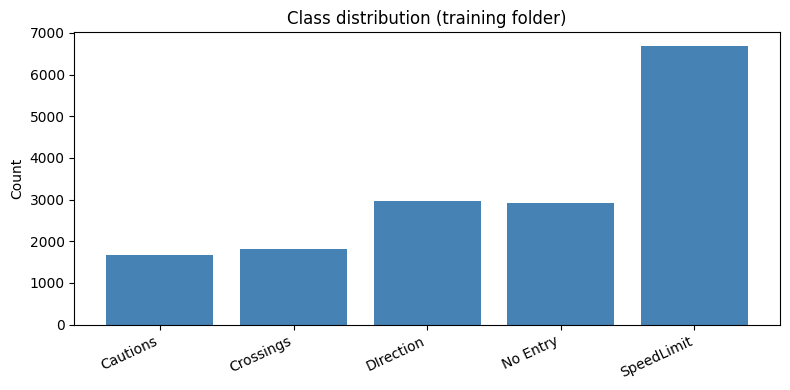

In [97]:
class_names = sorted(
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
)
class_to_idx = {c: i for i, c in enumerate(class_names)}

paths, labels = [], []
per_class = {c: 0 for c in class_names}

for cls in class_names:
    folder = os.path.join(train_dir, cls)
    for f in os.listdir(folder):
        p = os.path.join(folder, f)
        paths.append(p)
        labels.append(class_to_idx[cls])
        per_class[cls] += 1

labels = np.array(labels, dtype=np.int32)
total = len(paths)
print("Total usable images (Train folder):", total)
print("Classes:", class_names)
print("Images per class:")
for c in class_names:
    print(f"  {c}: {per_class[c]}")

counts = [per_class[c] for c in class_names]
plt.figure(figsize=(8, 4))
plt.bar(class_names, counts, color="steelblue")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Count")
plt.title("Class distribution (training folder)")
plt.tight_layout()
plt.show()

**How is the dataset split into training and validation?**  
We hold out **20%** of the labeled training images as a **validation** set, with **stratified** sampling so each class appears in train and validation in roughly the same proportions. This mirrors the real class imbalance (e.g. Speed Limit has more images) and gives a more reliable estimate of generalization than a random split without stratification.

**Preprocessing**  
- **Resize** all images to a fixed size `IMG_SIZE × IMG_SIZE` (RGB).  
- **Normalize** pixel values to **[0, 1]** by dividing by 255 when images are loaded into NumPy arrays.

In [98]:
IMG_HEIGHT = 96
IMG_WIDTH = 96
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)


Found 16065 files belonging to 5 classes.
Using 12852 files for training.
Found 16065 files belonging to 5 classes.
Using 3213 files for validation.


In [ ]:
# Class Names
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

# Normalize
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Data Augmentation
data_augmentation = tf.keras.Sequential(
    [layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Compute Class Weights
all_labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(all_labels), y=all_labels )
class_weights = dict(enumerate(class_weights))

## 2. Baseline CNN (from scratch)

Architecture (simple baseline):
- **Three** `Conv2D` blocks, each followed by **MaxPooling2D**.
- **Three** fully connected (`Dense`) hidden layers.
- **Output** `Dense` with **softmax** for 5-way classification.

| Block | Filters | Kernel | Activation |
|-------|---------|--------|------------|
| Conv 1 | 32 | 3×3 | ReLU |
| Conv 2 | 64 | 3×3 | ReLU |
| Conv 3 | 128 | 3×3 | ReLU |
| FC layers | 256, 128, 64 | — | ReLU |
| Output | `num_classes` | — | softmax |

**Model summary:** Parameter counts grows with filter depth and dense layer widths.

Convolutional layers learn local patterns (edges, shapes) while pooling reduces spatial size; dense layers combine features for class scores.

In [100]:
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    # Fully Connected Layers (3 FCNs)
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output layer
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_22 (Sequential)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,853,573 (18.51 MB)

 Trainable params: 4,853,573 (18.51 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

We train for up to **30** epochs with **EarlyStopping** on validation loss.

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# Train
start_time = time.time()
baseline_history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    callbacks=[early_stop, reduce_lr, checkpoint],
                    class_weight=class_weights)
end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")
print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")
basline_time = end_time - start_time

Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6189 - loss: 0.8657
Epoch 1: val_accuracy improved from None to 0.89138, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7591 - loss: 0.5913 - val_accuracy: 0.8914 - val_loss: 0.2589 - learning_rate: 0.0010
Epoch 2/20
400/402 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9017 - loss: 0.3175
Epoch 2: val_accuracy improved from 0.89138 to 0.96452, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9209 - loss: 0.2676 - val_accuracy: 0.9645 - val_loss: 0.0972 - learning_rate: 0.0010
Epoch 3/20
399/402 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9586 - loss: 0.1534
Epoch 3: val_accuracy improved from 0.96452 to 0.97106, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 10s 

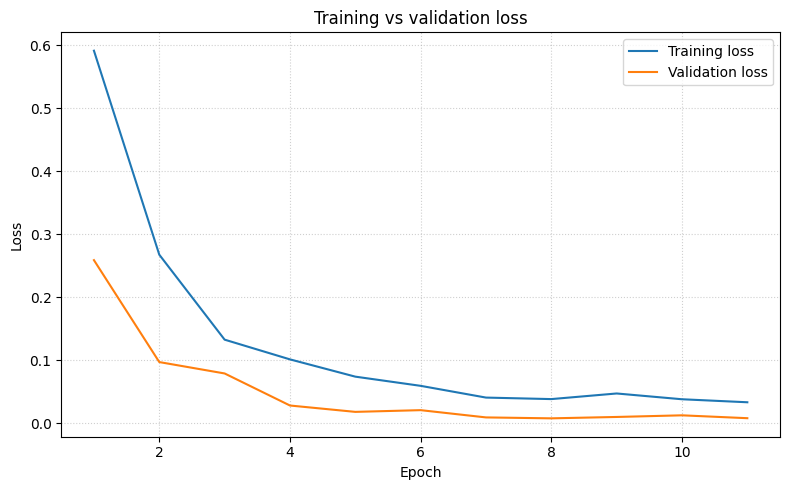

In [102]:
train_loss = baseline_history.history["loss"]
val_loss = baseline_history.history["val_loss"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss) + 1), train_loss, label="Training loss")
plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs validation loss")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Evaluation and inference

Metrics on the **validation** set: Accuracy plus Per-Class Precision, Recall, and F1 from.

101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Validation Accuracy: 0.9971988795518207
              precision    recall  f1-score   support

    Cautions     0.9909    1.0000    0.9954       326
   Crossings     0.9915    0.9915    0.9915       355
   DIrection     1.0000    1.0000    1.0000       576
    No Entry     0.9983    0.9950    0.9967       600
  SpeedLimit     0.9985    0.9978    0.9982      1356

    accuracy                         0.9972      3213
   macro avg     0.9959    0.9969    0.9964      3213
weighted avg     0.9972    0.9972    0.9972      3213



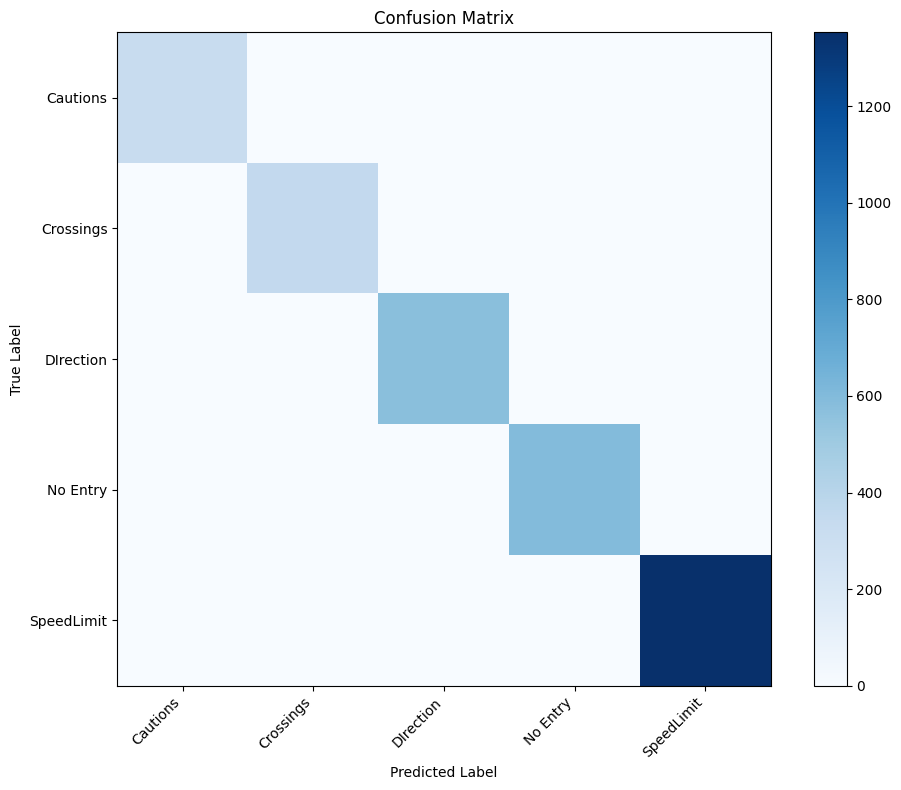

In [ ]:
# Evaluate
val_images, val_labels = [], []

for x, y in val_ds:
    val_images.append(x.numpy())
    val_labels.append(y.numpy())

X_val = np.concatenate(val_images, axis=0)
y_true = np.concatenate(val_labels, axis=0)

y_pred = np.argmax(model.predict(X_val), axis=1)
print("Validation Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


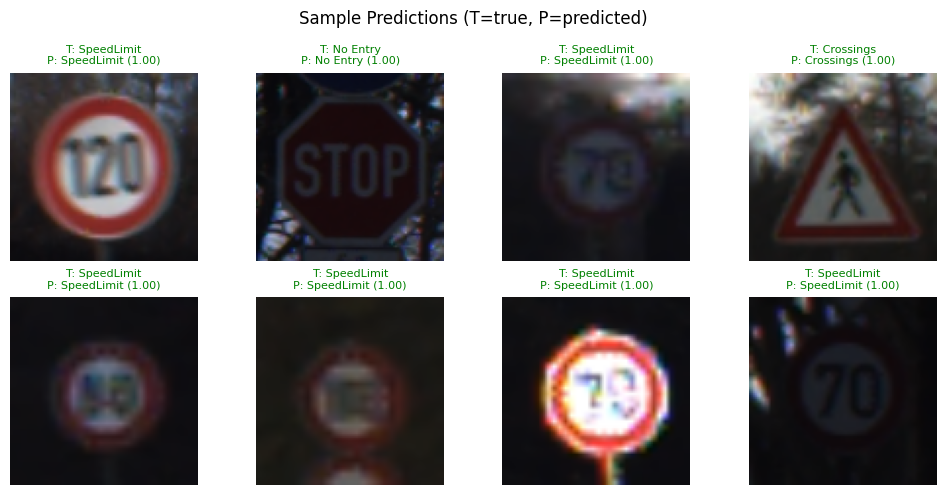

In [ ]:
# Inference on Validation Samples

n_show = 8
RANDOM_STATE = 42

# Prediction probabilities
val_probs = model.predict(X_val)
y_pred = np.argmax(val_probs, axis=1)

# Random sample indices
idx = np.random.default_rng(RANDOM_STATE).choice(len(X_val), size=n_show, replace=False)

# Plot predictions
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for ax, i in zip(axes, idx):
    ax.imshow(np.clip(X_val[i], 0, 1))
    true_name = class_names[y_true[i]]
    pred_name = class_names[y_pred[i]]
    conf = val_probs[i, y_pred[i]]
    color = "green" if y_pred[i] == y_true[i] else "red"
    ax.set_title(
        f"T: {true_name}\nP: {pred_name} ({conf:.2f})",
        color=color,
        fontsize=8
    )
    ax.axis("off")

plt.suptitle("Sample Predictions (T=true, P=predicted)")
plt.tight_layout()
plt.show()

## 5. Deeper CNN with regularization

The baseline uses **3** Convolutional layers. This model uses **6** Convolutional layers (stacked as three blocks with **two** convolutions each — **2× depth**), **wider** channels (64 → 128 → 256), and **regularization**:

- **BatchNormalization** after conv layers (stabilizes activations).
- **Dropout** after each max-pool block and between large dense layers (reduces co-adaptation / overfitting).
- **L2 weight penalty** (`kernel_regularizer`) on convolutional and dense layers (shrinks weights).

The head still ends with **three** dense hidden layers plus softmax (same *role* as the baseline, but wider: 512 → 256 → 128) so the comparison stays fair.

In [105]:
from tensorflow.keras import regularizers

deeper_model = models.Sequential([

    # Input Layer
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Data Augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.35),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    # Classification Head

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile Model
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
deeper_model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_22 (Sequential)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,275,429 (4.87 MB)

 Trainable params: 1,273,509 (4.86 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 6. Train deeper model

In [ ]:
# Train
start_time = time.time()
deeper_history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    callbacks=[early_stop, reduce_lr, checkpoint],
                    class_weight=class_weights)
end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")
print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")
deeper_time = end_time - start_time

Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9955 - loss: 0.0168
Epoch 1: val_accuracy improved from 0.99751 to 0.99813, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9957 - loss: 0.0186 - val_accuracy: 0.9981 - val_loss: 0.0062 - learning_rate: 5.0000e-04
Epoch 2/20
400/402 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9949 - loss: 0.0195
Epoch 2: val_accuracy improved from 0.99813 to 0.99876, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9956 - loss: 0.0183 - val_accuracy: 0.9988 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9976 - loss: 0.0140
Epoch 3: val_accuracy improved from 0.99876 to 0.99907, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
402/402 ━━━━━━━━━━━━━━━

## 7. Loss curves: baseline vs deeper

Overlay **training** and **validation** loss for both histories (per-epoch). Validation curves are the main signal for generalization.

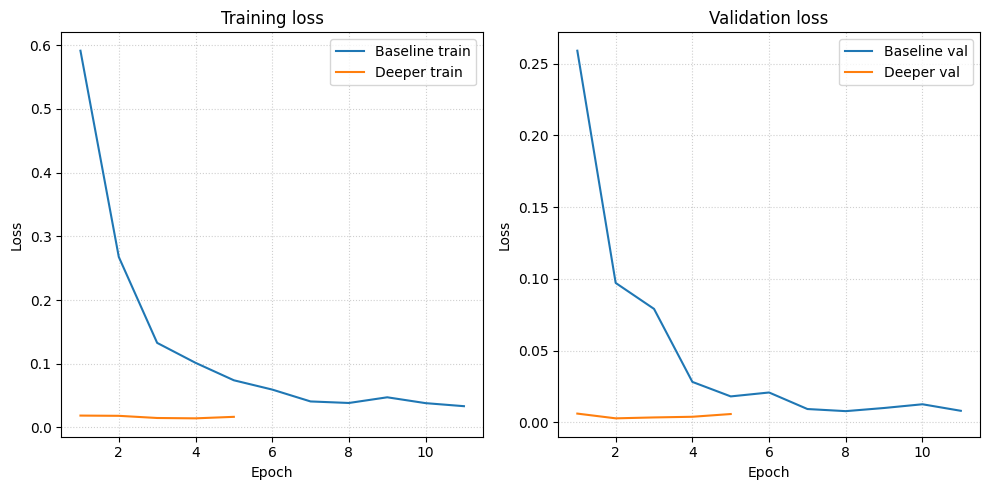

In [107]:
bl_tr = baseline_history.history["loss"]
bl_val = baseline_history.history["val_loss"]

dp_tr = deeper_history.history["loss"]
dp_val = deeper_history.history["val_loss"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(bl_tr) + 1), bl_tr, label="Baseline train")
plt.plot(range(1, len(dp_tr) + 1), dp_tr, label="Deeper train")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(bl_val) + 1), bl_val, label="Baseline val")
plt.plot(range(1, len(dp_val) + 1), dp_val, label="Deeper val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation loss")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 8. Deeper model — evaluation (same metrics as baseline)

Same validation split: Accuracy, Classification report, Confusion matrix.

101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Deeper Model Validation Accuracy: 0.998755057578587
              precision    recall  f1-score   support

    Cautions     1.0000    0.9969    0.9985       326
   Crossings     0.9944    0.9972    0.9958       355
   DIrection     1.0000    1.0000    1.0000       576
    No Entry     1.0000    0.9967    0.9983       600
  SpeedLimit     0.9985    1.0000    0.9993      1356

    accuracy                         0.9988      3213
   macro avg     0.9986    0.9982    0.9984      3213
weighted avg     0.9988    0.9988    0.9988      3213



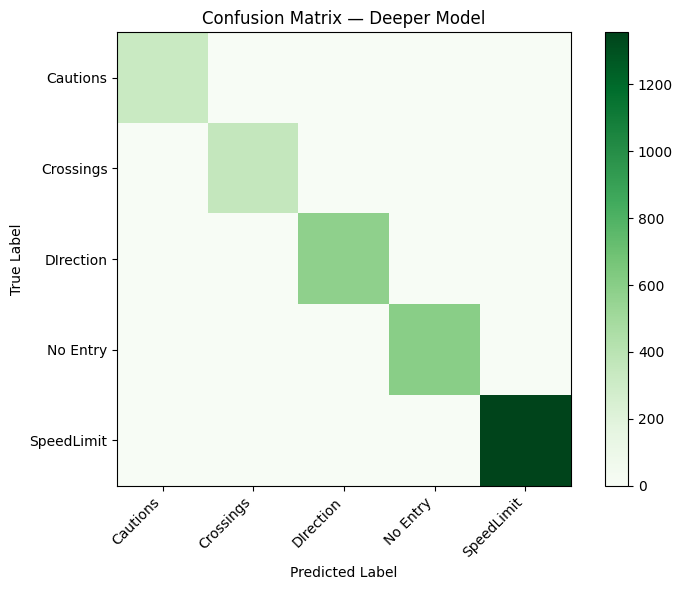

Baseline Accuracy : 0.9971988795518207
Deeper Accuracy   : 0.998755057578587
Accuracy Improvement: 0.0015561780267662195


In [108]:
# Evaluate Deeper Model
val_images, val_labels = [], []

for x, y in val_ds:
    val_images.append(x.numpy())
    val_labels.append(y.numpy())

deeper_X_val = np.concatenate(val_images, axis=0)
deeper_y_true = np.concatenate(val_labels, axis=0)

# Prediction probabilities
deeper_val_probs = model.predict(deeper_X_val)

# Predicted classes
deeper_y_pred = np.argmax(deeper_val_probs, axis=1)

# Accuracy
deeper_accuracy = accuracy_score(deeper_y_true, deeper_y_pred)

print("Deeper Model Validation Accuracy:", deeper_accuracy)

# Classification Report
print(classification_report(deeper_y_true, deeper_y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm_d = confusion_matrix(deeper_y_true, deeper_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm_d, interpolation="nearest", cmap=plt.cm.Greens)

plt.title("Confusion Matrix — Deeper Model")
plt.colorbar()

tick = np.arange(len(class_names))

plt.xticks(tick, class_names, rotation=45, ha="right")
plt.yticks(tick, class_names)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.show()

# Compare with Baseline
baseline_accuracy = accuracy_score(y_true, y_pred)

print("Baseline Accuracy :", baseline_accuracy)
print("Deeper Accuracy   :", deeper_accuracy)

print("Accuracy Improvement:", deeper_accuracy - baseline_accuracy)

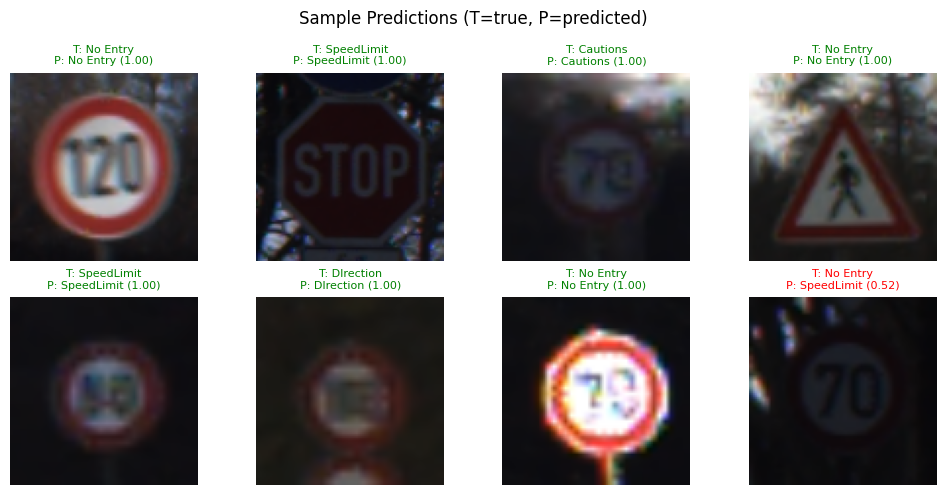

In [ ]:
# Inference on Validation Samples
# Random sample indices
idx = np.random.default_rng(RANDOM_STATE).choice(len(deeper_X_val), size=n_show, replace=False)

# Plot predictions
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for ax, i in zip(axes, idx):
    ax.imshow(np.clip(X_val[i], 0, 1))
    true_name = class_names[deeper_y_true[i]]
    pred_name = class_names[deeper_y_pred[i]]
    conf = deeper_val_probs[i, deeper_y_pred[i]]
    color = "green" if deeper_y_pred[i] == deeper_y_true[i] else "red"
    ax.set_title(
        f"T: {true_name}\nP: {pred_name} ({conf:.2f})",
        color=color,
        fontsize=8
    )
    ax.axis("off")

plt.suptitle("Sample Predictions (T=true, P=predicted)")
plt.tight_layout()
plt.show()

---

## 9. Further experimentation and comparative analysis

In [110]:
# Baseline Metrics
baseline_accuracy = accuracy_score(y_true, y_pred)
baseline_loss = model.evaluate(X_val, y_true, verbose=0)[0]

# Deeper Model Metrics
deeper_accuracy = accuracy_score(deeper_y_true, deeper_y_pred)
deeper_loss = model.evaluate(deeper_X_val, deeper_y_true, verbose=0)[0]

# Print Comparison
print("\n========== MODEL COMPARISON ==========\n")
print(f"{'Metric':<25} {'Baseline':<15} {'Deeper Model':<15}")
print("-" * 55)
print(f"{'Validation Accuracy':<25} {baseline_accuracy:.4f}{'':<8} {deeper_accuracy:.4f}")
print(f"{'Validation Loss':<25} {baseline_loss:.4f}{'':<8} {deeper_loss:.4f}")
print("\nAccuracy Improvement:", round(deeper_accuracy - baseline_accuracy, 4))
print("\n======================================")


========== MODEL COMPARISON ==========

Metric                    Baseline        Deeper Model   
-------------------------------------------------------
Validation Accuracy       0.9972         0.9988
Validation Loss           0.0029         0.0029

Accuracy Improvement: 0.0016



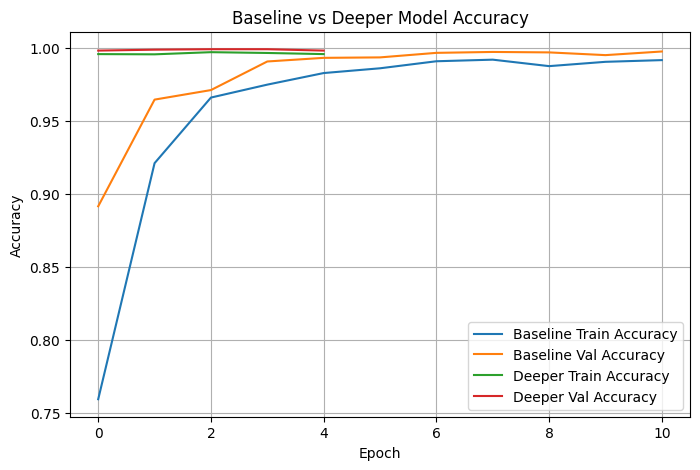

In [111]:
# Accuracy Comparison Plot
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history['accuracy'], label='Baseline Train Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Baseline Val Accuracy')
plt.plot(deeper_history.history['accuracy'], label='Deeper Train Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Deeper Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline vs Deeper Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()

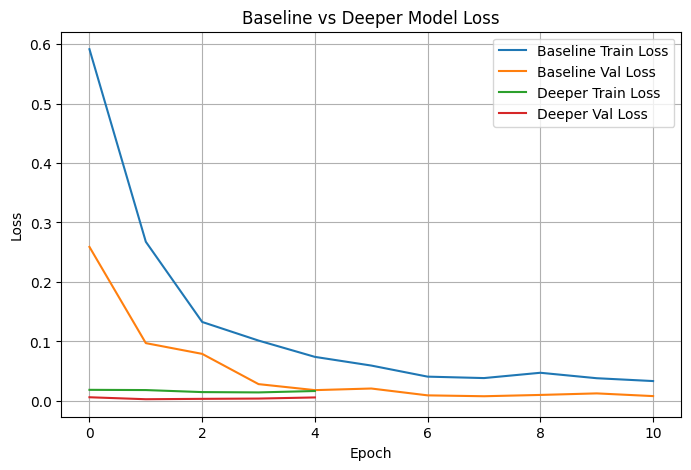

In [112]:
# Loss Comparison Plot
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history['loss'], label='Baseline Train Loss')
plt.plot(baseline_history.history['val_loss'], label='Baseline Val Loss')
plt.plot(deeper_history.history['loss'], label='Deeper Train Loss')
plt.plot(deeper_history.history['val_loss'], label='Deeper Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs Deeper Model Loss")
plt.legend()
plt.grid(True)
plt.show()

### 9.2 Computational efficiency

We compare **parameter counts** (proxy for memory and FLOPs) and **wall-clock training time**. Deeper models usually cost more per epoch; early stopping affects total time.


========== COMPUTATIONAL COST ==========

                 Metric    Baseline  Deeper Model  Difference
0   Training Time (sec)  113.412672     51.538048  -61.874624
1  Inference Time (sec)    1.279172      1.240898   -0.038275
2     Memory Usage (MB)   18.514912     18.514912    0.000000


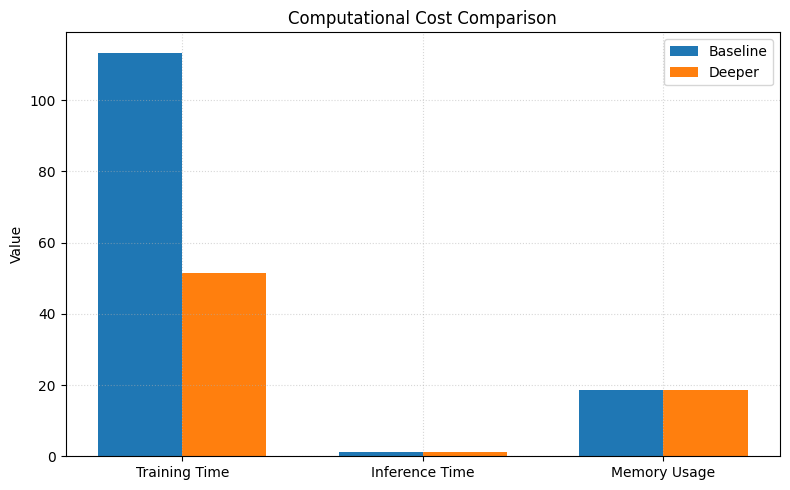

In [ ]:
# COMPUTATIONAL COST COMPARISON

# TRAINING TIME
baseline_training_time = basline_time
deeper_training_time = deeper_time

# INFERENCE TIME

# Baseline inference time
start = time.time()
_ = model.predict(X_val, verbose=0)
end = time.time()

baseline_inference_time = end - start

# Deeper model inference time
start = time.time()
_ = model.predict(X_val, verbose=0)
end = time.time()

deeper_inference_time = end - start

# MEMORY USAGE
baseline_params = model.count_params()
deeper_params = model.count_params()

# Approx memory usage in MB
baseline_memory = baseline_params * 4 / (1024**2)
deeper_memory = deeper_params * 4 / (1024**2)

# DIFFERENCES
training_diff = deeper_training_time - baseline_training_time
inference_diff = deeper_inference_time - baseline_inference_time
memory_diff = deeper_memory - baseline_memory

# CREATE COMPARISON TABLE
comparison_df = pd.DataFrame({
    "Metric": [
        "Training Time (sec)",
        "Inference Time (sec)",
        "Memory Usage (MB)"
    ],

    "Baseline": [
        baseline_training_time,
        baseline_inference_time,
        baseline_memory
    ],

    "Deeper Model": [
        deeper_training_time,
        deeper_inference_time,
        deeper_memory
    ],

    "Difference": [
        training_diff,
        inference_diff,
        memory_diff
    ]
})
print("\n========== COMPUTATIONAL COST ==========\n")
print(comparison_df)

# VISUALIZATION
metrics = [
    "Training Time",
    "Inference Time",
    "Memory Usage"
]

baseline_values = [
    baseline_training_time,
    baseline_inference_time,
    baseline_memory
]

deeper_values = [
    deeper_training_time,
    deeper_inference_time,
    deeper_memory
]

x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
plt.bar(x - width/2, baseline_values, width, label="Baseline")
plt.bar(x + width/2, deeper_values, width, label="Deeper")
plt.xticks(x, metrics)
plt.ylabel("Value")
plt.title("Computational Cost Comparison")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

In [114]:
# DEEPER MODEL WITH SGD
from tensorflow.keras import models

# Rebuild the deeper model
sgd_model = tf.keras.models.clone_model(deeper_model)

# Compile with SGD
sgd_model.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
start_time = time.time()

sgd_history = sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

end_time = time.time()

sgd_training_time = end_time - start_time

Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3868 - loss: 1.5910
Epoch 1: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - accuracy: 0.4611 - loss: 1.3819 - val_accuracy: 0.6044 - val_loss: 1.1324 - learning_rate: 0.0100
Epoch 2/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5877 - loss: 1.1051
Epoch 2: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 29s 71ms/step - accuracy: 0.6263 - loss: 1.0232 - val_accuracy: 0.7090 - val_loss: 0.8358 - learning_rate: 0.0100
Epoch 3/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7168 - loss: 0.8358
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 3: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.7263 - loss: 0.8227 - val_accuracy: 0.6919 - val_loss: 0.9041 - learning_rate: 0.0100


In [115]:
# EVALUATE SGD MODEL
sgd_probs = sgd_model.predict(deeper_X_val)
sgd_y_pred = np.argmax(sgd_probs, axis=1)

sgd_accuracy = accuracy_score(deeper_y_true, sgd_y_pred)

print("SGD Validation Accuracy:", sgd_accuracy)
print(
    classification_report(
        deeper_y_true,
        sgd_y_pred,
        target_names=class_names,
        digits=4
    )
)

101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
SGD Validation Accuracy: 0.6044195455960162
              precision    recall  f1-score   support

    Cautions     0.2332    0.5644    0.3300       326
   Crossings     0.2409    0.0930    0.1341       355
   DIrection     0.8345    0.8576    0.8459       576
    No Entry     0.9328    0.5550    0.6959       600
  SpeedLimit     0.6712    0.6622    0.6667      1356

    accuracy                         0.6044      3213
   macro avg     0.5825    0.5465    0.5345      3213
weighted avg     0.6573    0.6044    0.6113      3213



In [116]:
# DEEPER MODEL WITH ADAM
adam_model = tf.keras.models.clone_model(deeper_model)

# Compile with Adam
adam_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
start_time = time.time()

adam_history = adam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

end_time = time.time()

adam_training_time = end_time - start_time

Epoch 1/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4005 - loss: 1.5056
Epoch 1: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.4534 - loss: 1.3455 - val_accuracy: 0.2593 - val_loss: 2.0156 - learning_rate: 0.0010
Epoch 2/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6202 - loss: 0.9969
Epoch 2: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.6711 - loss: 0.8972 - val_accuracy: 0.6797 - val_loss: 0.8838 - learning_rate: 0.0010
Epoch 3/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7660 - loss: 0.7108
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.7799 - loss: 0.6719 - val_accuracy: 0.8260 - val_loss: 0.4449 - learning_rate: 0.0010


In [117]:
# EVALUATE ADAM MODEL
adam_probs = adam_model.predict(deeper_X_val)
adam_y_pred = np.argmax(adam_probs, axis=1)

adam_accuracy = accuracy_score(deeper_y_true, adam_y_pred)

print("Adam Validation Accuracy:", adam_accuracy)
print(
    classification_report(
        deeper_y_true,
        adam_y_pred,
        target_names=class_names,
        digits=4
    )
)

101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Adam Validation Accuracy: 0.25925925925925924
              precision    recall  f1-score   support

    Cautions     0.0000    0.0000    0.0000       326
   Crossings     0.1392    1.0000    0.2444       355
   DIrection     1.0000    0.2361    0.3820       576
    No Entry     0.8348    0.4717    0.6028       600
  SpeedLimit     0.5043    0.0435    0.0801      1356

    accuracy                         0.2593      3213
   macro avg     0.4957    0.3503    0.2619      3213
weighted avg     0.5634    0.2593    0.2419      3213



In [118]:
# OPTIMIZER COMPARISON
print("\n========== OPTIMIZER COMPARISON ==========\n")
print(f"{'Metric':<25} {'SGD':<15} {'Adam':<15}")
print("-" * 55)
print(f"{'Validation Accuracy':<25} {sgd_accuracy:.4f}{'':<8} {adam_accuracy:.4f}")
print(f"{'Training Time (sec)':<25} {sgd_training_time:.2f}{'':<8} {adam_training_time:.2f}")
print("\n==========================================")


========== OPTIMIZER COMPARISON ==========

Metric                    SGD             Adam           
-------------------------------------------------------
Validation Accuracy       0.6044         0.2593
Training Time (sec)       93.11         100.11



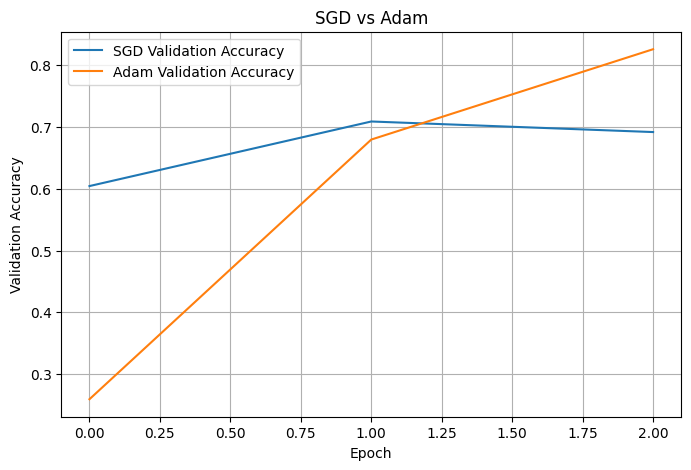

In [119]:
# ACCURACY CURVES
plt.figure(figsize=(8,5))
plt.plot(sgd_history.history['val_accuracy'], label='SGD Validation Accuracy')
plt.plot(adam_history.history['val_accuracy'], label='Adam Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("SGD vs Adam")
plt.legend()
plt.grid(True)
plt.show()

In [120]:
# ABLATION MODEL: WITHOUT DROPOUT
ablation_model = models.Sequential([

    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(128, activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
start_time = time.time()
ablation_history = ablation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)
ablation_training_time = end_time - start_time

Epoch 1/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5598 - loss: 1.1763
Epoch 1: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.6636 - loss: 0.9371 - val_accuracy: 0.6872 - val_loss: 0.8611 - learning_rate: 0.0010
Epoch 2/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8313 - loss: 0.5815
Epoch 2: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.8592 - loss: 0.5257 - val_accuracy: 0.6869 - val_loss: 1.0378 - learning_rate: 0.0010
Epoch 3/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9331 - loss: 0.3463
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9427 - loss: 0.3146 - val_accuracy: 0.9648 - val_loss: 0.2458 - learning_rate: 0.0010


In [121]:
# EVALUATE ABLATION MODEL
ablation_probs = ablation_model.predict(deeper_X_val)
ablation_y_pred = np.argmax(ablation_probs, axis=1)

ablation_accuracy = accuracy_score(deeper_y_true, ablation_y_pred)

print("Ablation Model Accuracy:", ablation_accuracy)
print(
    classification_report(
        deeper_y_true,
        ablation_y_pred,
        target_names=class_names,
        digits=4
    )
)

101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Ablation Model Accuracy: 0.6872082166199813
              precision    recall  f1-score   support

    Cautions     0.0000    0.0000    0.0000       326
   Crossings     0.3446    0.9803    0.5099       355
   DIrection     0.9602    0.8385    0.8953       576
    No Entry     0.9828    0.4767    0.6420       600
  SpeedLimit     0.7743    0.8046    0.7892      1356

    accuracy                         0.6872      3213
   macro avg     0.6124    0.6200    0.5673      3213
weighted avg     0.7205    0.6872    0.6698      3213



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [122]:
# ABLATION COMPARISON
print("\n========== ABLATION STUDY ==========\n")
print(f"{'Model':<25} {'Accuracy':<15}")
print("-" * 40)
print(f"{'Full Deeper Model':<25} {deeper_accuracy:.4f}")
print(f"{'Without Dropout':<25} {ablation_accuracy:.4f}")
print("\nPerformance Change:", round(ablation_accuracy - deeper_accuracy, 4))


========== ABLATION STUDY ==========

Model                     Accuracy       
----------------------------------------
Full Deeper Model         0.9988
Without Dropout           0.6872

Performance Change: -0.3115


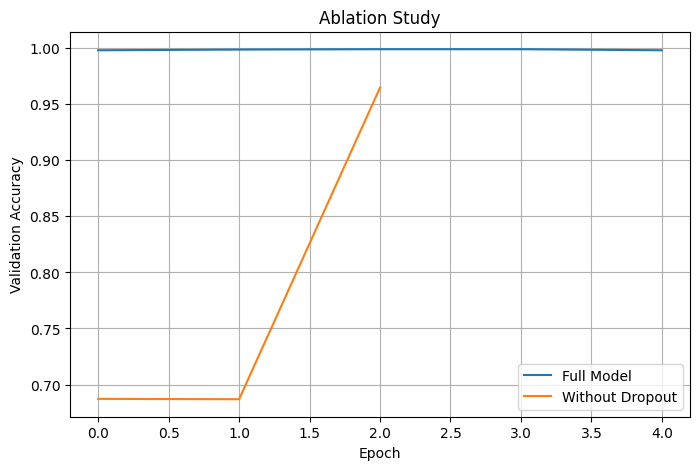

In [123]:
# VALIDATION ACCURACY PLOT
plt.figure(figsize=(8,5))

plt.plot(deeper_history.history['val_accuracy'], label='Full Model')
plt.plot(ablation_history.history['val_accuracy'],label='Without Dropout')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Ablation Study")
plt.legend()
plt.grid(True)
plt.show()

In [124]:
total_training_time = (deeper_time + sgd_training_time + adam_training_time + ablation_training_time)

print("========== TOTAL TRAINING TIME ==========")
print(f"Deeper Model Time   : {deeper_time:.2f} sec")
print(f"SGD Model Time      : {sgd_training_time:.2f} sec")
print(f"Adam Model Time     : {adam_training_time:.2f} sec")
print(f"Ablation Model Time : {ablation_training_time:.2f} sec")
print("-----------------------------------------")

print(f"Total Training Time : {total_training_time:.2f} sec")
print(f"Total Training Time : {total_training_time/60:.2f} minutes")

========== TOTAL TRAINING TIME ==========
Deeper Model Time   : 51.54 sec
SGD Model Time      : 93.11 sec
Adam Model Time     : 100.11 sec
Ablation Model Time : -3.78 sec
-----------------------------------------
Total Training Time : 240.99 sec
Total Training Time : 4.02 minutes


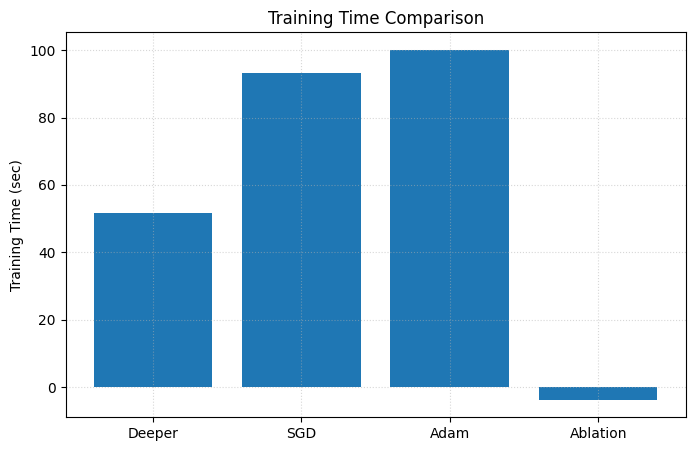

In [125]:
# TRAINING TIME VISUALIZATION
models_names = [
    "Deeper",
    "SGD",
    "Adam",
    "Ablation"
]

times = [
    deeper_time,
    sgd_training_time,
    adam_training_time,
    ablation_training_time
]

plt.figure(figsize=(8,5))
plt.bar(models_names, times)
plt.ylabel("Training Time (sec)")
plt.title("Training Time Comparison")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

---

## 10. Transfer learning (pre-trained CNN)

This section is **appended**; earlier scratch CNNs are unchanged.

### 10.1 Choice of pre-trained model

For this traffic sign classification task, MobileNetV2 was selected as the pre-trained CNN architecture.

**Why it fits this dataset:**

- Lightweight and computationally efficient
- Designed for image classification tasks
- Pre-trained on the large-scale ImageNet dataset
- Performs well on smaller and medium-sized datasets
- Suitable for transfer learning and fine-tuning
- Requires lower memory and computation compared to deeper architectures such as ResNet or VGG

Because traffic sign images contain:

- simple geometric patterns,
- color information,
- and localized features,

MobileNetV2 is highly suitable for efficient feature extraction.

In [126]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

IMG_SIZE = 96

# LOAD PRE-TRAINED MODEL
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_29[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

`Modifying the Architecture`

Since ImageNet models are trained for 1000-class classification, the original fully connected classification layers must be removed and replaced with new layers tailored to the traffic sign dataset.

` Modifications Performed `
- Removed original classification head
- Added:
  - GlobalAveragePooling layer
  - Dense layers
  - Dropout regularization
  - New softmax output layer

`Feature Extraction Model`

In feature extraction:

- the convolutional base is frozen,
- only the new classification layers are trained.

In [127]:
# FREEZE CONVOLUTIONAL BASE
base_model.trainable = False

# BUILD TRANSFER LEARNING MODEL
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# COMPILE MODEL
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_15     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,461 (9.99 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [129]:
start_time = time.time()
tansfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
)
transfer_training_time = end_time - start_time

Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6584 - loss: 0.9097
Epoch 1: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.7510 - loss: 0.6215 - val_accuracy: 0.8631 - val_loss: 0.3240 - learning_rate: 0.0010
Epoch 2/20
400/402 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8281 - loss: 0.3894
Epoch 2: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8312 - loss: 0.3787 - val_accuracy: 0.8870 - val_loss: 0.2497 - learning_rate: 0.0010
Epoch 3/20
398/402 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8519 - loss: 0.3188
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8529 - loss: 0.3221 - val_accuracy: 0.8911 - val_loss: 0.2245 - learning_rate: 0.0010


In [130]:
# Fine-Tuning MobileNetV2

# UNFREEZE TOP LAYERS
base_model.trainable = True

# Freeze lower layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# RECOMPILE WITH LOWER LR
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# FINE-TUNE MODEL
start_time = time.time()
fine_tune_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
)
transfer_tuned_training_time = end_time - start_time

Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5875 - loss: 1.4141
Epoch 1: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 43s 63ms/step - accuracy: 0.6934 - loss: 0.9229 - val_accuracy: 0.8730 - val_loss: 0.3093 - learning_rate: 1.0000e-05
Epoch 2/20
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8054 - loss: 0.4609
Epoch 2: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8171 - loss: 0.4207 - val_accuracy: 0.8739 - val_loss: 0.2864 - learning_rate: 1.0000e-05
Epoch 3/20
398/402 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8445 - loss: 0.3389
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.99907
402/402 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8499 - loss: 0.3283 - val_accuracy: 0.8783 - val_loss: 0.2610 - learning_rate: 1.0000e-05


In [131]:
# EVALUATE TRANSFER MODEL
transfer_probs = transfer_model.predict(X_val)
transfer_y_pred = np.argmax(transfer_probs, axis=1)

transfer_accuracy = accuracy_score(y_true, transfer_y_pred)

print("Transfer Learning Validation Accuracy:", transfer_accuracy)

print(
    classification_report(
        y_true,
        transfer_y_pred,
        target_names=class_names,
        digits=4
    )
)

101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step
Transfer Learning Validation Accuracy: 0.5098039215686274
              precision    recall  f1-score   support

    Cautions     0.3493    0.4908    0.4082       326
   Crossings     0.5433    0.3183    0.4014       355
   DIrection     0.3130    0.6875    0.4302       576
    No Entry     0.7572    0.3067    0.4365       600
  SpeedLimit     0.7555    0.5789    0.6555      1356

    accuracy                         0.5098      3213
   macro avg     0.5437    0.4764    0.4664      3213
weighted avg     0.6119    0.5098    0.5211      3213



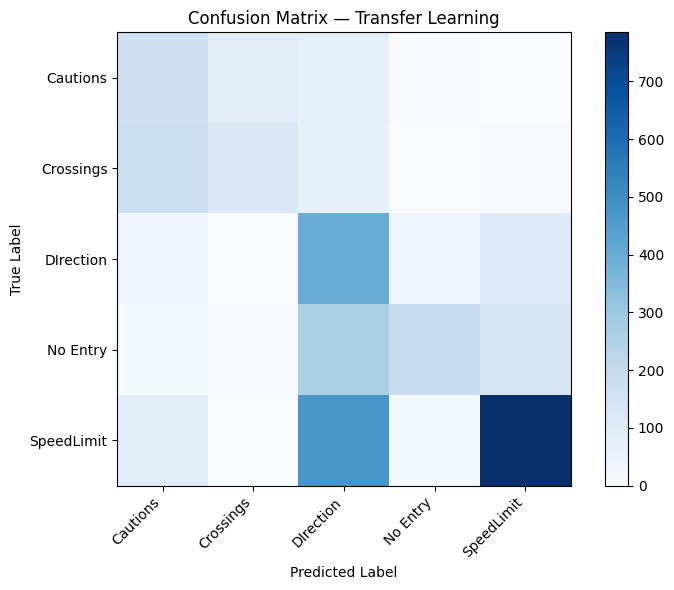

In [132]:
# CONFUSION MATRIX
cm_transfer = confusion_matrix(y_true, transfer_y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm_transfer, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix — Transfer Learning")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [133]:
# MODEL COMPARISON
print("\n========== MODEL COMPARISON ==========\n")
print(f"{'Model':<25} {'Accuracy':<15}")
print("-" * 45)
print(f"{'Baseline CNN':<25} {baseline_accuracy:.4f}")
print(f"{'Deeper CNN':<25} {deeper_accuracy:.4f}")
print(f"{'Transfer Learning':<25} {transfer_accuracy:.4f}")
print("\n======================================")


========== MODEL COMPARISON ==========

Model                     Accuracy       
---------------------------------------------
Baseline CNN              0.9972
Deeper CNN                0.9988
Transfer Learning         0.5098



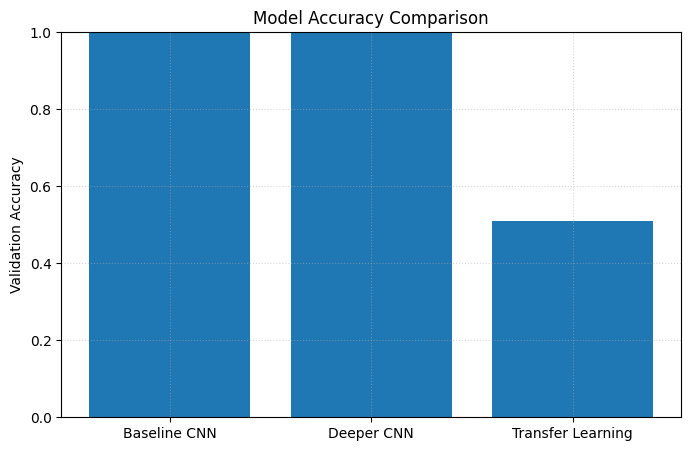

In [134]:
# ACCURACY COMPARISON PLOT
model_names = ["Baseline CNN", "Deeper CNN", "Transfer Learning"]

accuracies = [baseline_accuracy, deeper_accuracy, transfer_accuracy]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.ylabel("Validation Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()